In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    AND labname = 'project1'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:45.549397
2,user_4,2020-04-17 05:34:24.422370
3,user_4,2020-04-17 05:43:27.773992
4,user_4,2020-04-17 05:46:32.275104


## Prepare cumulative commits per user

In [3]:
commits = commits.sort_values('timestamp')
commits['cum_commits'] = commits.groupby('uid').cumcount() + 1
commits.head()

,uid,timestamp,cum_commits
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5


## Plot with Seaborn

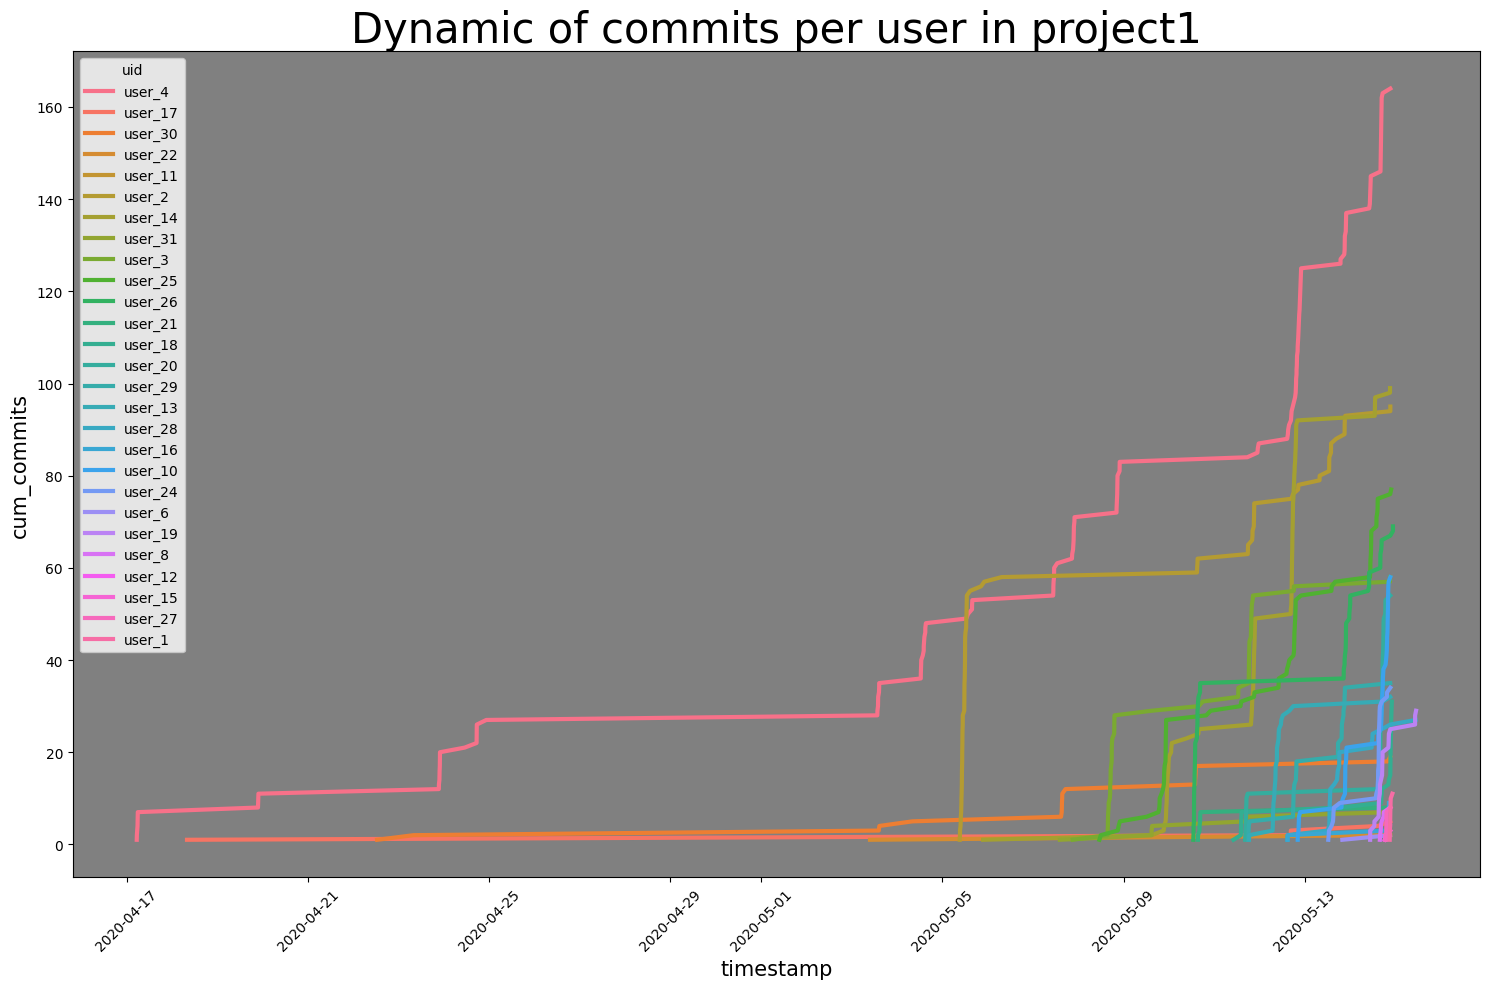

In [4]:
height = 10
width = height * 1.5

fig, ax = plt.subplots(figsize=(width, height))
ax.set_facecolor('gray')

sns.lineplot(
    data=commits,
    x='timestamp',
    y='cum_commits',
    hue='uid',
    linewidth=3,
    ax=ax
)

ax.set_title('Dynamic of commits per user in project1', fontsize=30)
ax.set_xlabel('timestamp', fontsize=15)
ax.set_ylabel('cum_commits', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Answer questions

In [5]:
# User with most commits overall (leader almost all the time)
total = commits.groupby('uid')['cum_commits'].max().sort_values(ascending=False)
print('Total commits per user:')
print(total)
print(f'\nLeader almost all the time: {total.index[0]}')
print(f'Leader for only a short period: {total.index[-1]}')

Total commits per user:
uid
user_4     164
user_14     99
user_2      95
user_25     77
user_26     69
user_3      58
user_10     58
user_20     54
user_29     35
user_24     34
user_13     32
user_18     31
user_19     29
user_28     27
user_30     19
user_1      11
user_21      9
user_16      9
user_27      8
user_31      8
user_8       8
user_17      5
user_12      4
user_15      3
user_22      2
user_6       2
user_11      1
Name: cum_commits, dtype: int64

Leader almost all the time: user_4
Leader for only a short period: user_11


Which user was the leader in the number of commits almost all of the time? The answer is user_*: user_4.

Which user was the leader for only a short period of time? The answer is user_*: user_11.